# Benchmark for Thompson Sampling

In [1]:
import json
import os
import random
from copy import deepcopy
from scoring_service.HumanityScorer import scorer

# --- Configuration ---
DATA_DIR = "data"
# MODEL_SAVE_PATH = "models/offline_rl_model.pth"

# Simulation Hyperparameters
TARGET_HUMAN_COUNT = int(random.random() * 20) + 80   # Between 80-100  # Number of "real" human users to simulate
TARGET_BOT_COUNT = random.choice([0, 20, 50, 100, 200, 1000])  # Number of bot users to simulate (for DoS)
SIMULATION_STEP_SECONDS = 10  # How often the RL agent is called (matches frontend)
SESSION_CHUNK_SIZE = int(SIMULATION_STEP_SECONDS * 1000)  # In milliseconds

conf = {
    "human": {"predicted": {"human": 0, "bot": 0}},
    "bot": {"predicted": {"human": 0, "bot": 0}}
}

In [2]:
def update_human_bot_population(human_count=None, bot_count=None):
    global TARGET_HUMAN_COUNT, TARGET_BOT_COUNT, conf
    TARGET_HUMAN_COUNT = random.randint(80, 100) if human_count is None else human_count
    TARGET_BOT_COUNT = random.choice([0, 20, 50, 100, 200, 1000]) if bot_count is None else bot_count
    
    # Reset Confusion Matrix for the new episode
    for key in ["human", "bot"]:
        for pred in ["human", "bot"]:
            conf[key]["predicted"][pred] = 0

def get_humanity_score(mouse_movement):
    if not mouse_movement:
        return None
    formatted_movements = [[m['x'], m['y']] for m in mouse_movement]
    try:
        # Assuming scorer is the LSTM model
        prediction = scorer.predict(formatted_movements)
        return float(prediction)
    except Exception as e:
        return 0.5
    

def load_session_data(data_dir):
    """Loads all human and bot raw data files."""
    human_sessions = []
    bot_sessions = []
    print(f"Loading raw session data from {data_dir}...")
    for filename in os.listdir(data_dir):
        if not filename.endswith('.json'): continue
        filepath = os.path.join(data_dir, filename)
        try:
            with open(filepath, 'r') as f:
                data = json.load(f)
            if filename.startswith('human'):
                human_sessions.append(data)
            elif filename.startswith('bot'):
                bot_sessions.append(data)
        except Exception as e:
            print(f"Warning: Could not load or parse {filename}. Error: {e}")

    print(f"Loaded {len(human_sessions)} human sessions and {len(bot_sessions)} bot sessions.")
    if not human_sessions or not bot_sessions:
        print("Error: Not enough data to run simulation. Please run bot simulator and browse site.")
        exit()
    return human_sessions, bot_sessions


def perturb_mouse_data(movements):
    """Creates a 'new' user by slightly altering existing mouse data."""
    if not movements: return []
    # Add small random noise to each coordinate
    noise_x = random.randint(-5//5, 5//5)
    noise_y = random.randint(-5//5, 5//5)
    return [{**m, 'x': m['x'] + noise_x, 'y': m['y'] + noise_y, 'timestamp': m['timestamp']} for m in movements]


def get_session_chunks(session_data, chunk_size_ms, target_chunks_size=12):
    """Splits a full session's mouse data into 10-second (step) chunks."""
    start_time = session_data['timestamps']['start']
    movements = session_data.get('mouse_movements', [])
    if not movements: return [[]]  # Return one empty chunk

    chunks = []
    current_chunk = []
    chunk_end_time = start_time + chunk_size_ms

    for move in movements:
        if move['timestamp'] <= chunk_end_time:
            current_chunk.append(move)
        else:
            chunks.append(current_chunk)
            if len(chunks) == target_chunks_size:
                return chunks
            # Handle multiple empty steps
            while move['timestamp'] > chunk_end_time + chunk_size_ms:
                chunks.append([])
                if len(chunks) == target_chunks_size:
                    return chunks
                chunk_end_time += chunk_size_ms

            current_chunk = [move]
            chunk_end_time += chunk_size_ms

    chunks.append(current_chunk)  # Add the last chunk
    if len(chunks) < target_chunks_size:
        chunks = chunks + get_session_chunks(session_data, chunk_size_ms, target_chunks_size=target_chunks_size - len(chunks))
    return chunks

class SimulatedUser:
    """Represents a single concurrent user (bot or human) in the simulation."""

    def __init__(self, base_session_data, is_bot):
        self.is_bot = is_bot
        self.client_id = f"{'bot' if is_bot else 'human'}_{random.randint(10000, 99999)}"
        self.captchas_solved = 0
        self.last_captcha_solved = -1
        self.done = False  # Is this user's session over?
        self.last_humanity_score = None
        self.average_humanity_score = 0.5
        self.n_humanity_score = 0

        # *** NEW: Assign a "strength" to each bot ***
        # This is the max threat level (0-9) the bot can "beat"
        # A threat level of 10 will *always* kill the bot.
        if self.is_bot:
            self.bot_strength = random.randint(0, 9)
        else:
            self.bot_strength = None  # Humans don't have a strength

        # Perturb and chunk the data to create a new, unique session
        perturbed_movements = perturb_mouse_data(base_session_data.get('mouse_movements', []))
        perturbed_session = {**base_session_data, 'mouse_movements': perturbed_movements}
        self.session_chunks = get_session_chunks(perturbed_session, SESSION_CHUNK_SIZE)
        self.current_chunk_index = 0

    def get_step_data(self):
        """Gets the mouse data for the current 10-second step."""
        if self.done or self.current_chunk_index >= len(self.session_chunks):
            self.done = True
            return None  # This user has finished their session

        chunk = self.session_chunks[self.current_chunk_index]
        self.current_chunk_index += 1
        return chunk
    
    def update_stats(self, h_score):
        if h_score is not None:
            self.last_humanity_score = h_score
            self.average_humanity_score = (self.average_humanity_score * self.n_humanity_score + h_score) / (self.n_humanity_score + 1)
            self.n_humanity_score += 1


    def reset_session(self):
        """Called when a bot is 'killed'."""
        self.captchas_solved = 0
        self.done = True

In [3]:
import math

def calculate_reward(user, threat_level):
    """
    Refined reward function for balancing Security vs. UX.
    Weights are normalized so that one 'Happy Human' is roughly 
    equivalent to one 'Caught Bot'.
    """
    reward = 0
    done = False
    
    # Constants for tuning
    MAX_REWARD = 50.0        # Baseline for a 'Perfect' action
    LEAKAGE_PENALTY = -150.0 # Bot got through (Critical Failure)
    FRICTION_BASE = 2.0      # Sensitivity to human annoyance
    
    if user.is_bot:
        if threat_level > user.bot_strength:
            # Bot CAUGHT
            # We want the lowest threat level that still beats the bot.
            # Overkill penalty: (threat_level - strength) 
            overkill = (threat_level - user.bot_strength)
            reward = MAX_REWARD - (overkill * 2.0) 
            done = True
            user.reset_session()
        else:
            # Bot LEAKED
            # Penalty scales with how much the bot 'outsmarted' the system
            gap = user.bot_strength - threat_level
            reward = LEAKAGE_PENALTY - (gap * 5.0)
            user.captchas_solved += 1
            
    else:
        # HUMAN logic
        if threat_level == 0:
            # Perfect score for zero friction
            reward = MAX_REWARD
        else:
            # Non-linear frustration: Level 1 is okay, Level 10 is infuriating.
            # Using an exponential penalty for human annoyance.
            frustration = math.pow(FRICTION_BASE, threat_level)
            reward = (MAX_REWARD / 2.0) - frustration
            
        user.captchas_solved += 1

        # Check if human gave up (Simulated patience)
        if threat_level == 10 or random.random() * (threat_level - 6) > 0.5:
            done = True # Human abandoned site due to high friction

    return reward, done

In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim

# class FeatureNN(nn.Module):
#     def __init__(self, input_dim=5, embed_dim=32):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(input_dim, 64),
#             nn.ReLU(),
#             nn.Linear(64, embed_dim)
#         )

#     def forward(self, x):
#         return self.net(x)

# class DeepContextualBandit:
#     def __init__(self, num_arms=5, context_dim=5, embed_dim=32, alpha=1.0, lr=1e-3):
#         self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#         self.num_arms = num_arms
#         self.alpha = alpha

#         # neural network embedding
#         self.feature_nn = FeatureNN(context_dim, embed_dim).to(self.device)
#         self.optimizer = optim.Adam(self.feature_nn.parameters(), lr=lr)

#         # UCB "linear head" parameters
#         self.embed_dim = embed_dim
#         self.As = [torch.eye(embed_dim).to(self.device) for _ in range(num_arms)]
#         self.bs = [torch.zeros(embed_dim).to(self.device) for _ in range(num_arms)]

#     def select_action(self, context):
#         """
#         Get UCB scores for each arm and pick best.
#         context: torch.Tensor shape (context_dim,)
#         """
#         z = self.feature_nn(context.to(self.device))  # embed

#         best_arm = None
#         best_score = -float('inf')

#         with torch.no_grad():
#             for a in range(self.num_arms):
#                 A = self.As[a]
#                 b = self.bs[a]

#                 invA = torch.linalg.inv(A)
#                 theta_hat = invA @ b  # linear estimate

#                 mean = z @ theta_hat
#                 # UCB uncertainty
#                 unc = self.alpha * torch.sqrt((z @ invA) @ z)
#                 score = mean + unc

#                 if score > best_score:
#                     best_score = score
#                     best_arm = a

#         return best_arm

#     def update(self, context, action, reward):
#         """
#         Update linear head and train features with supervised signal.
#         """
#         context = context.to(self.device)
#         reward = torch.tensor(reward, dtype=torch.float32, device=self.device)

#         # get feature
#         z = self.feature_nn(context)

#         # ----------- Update linear head (NO GRAD) -----------
#         with torch.no_grad():
#             z_detached = z.detach()
#             # update linear model for chosen arm
#             A = self.As[action]
#             b = self.bs[action]

#             self.As[action] = A + torch.outer(z_detached, z_detached)
#             self.bs[action] = b + reward * z_detached
#         # # update linear model for chosen arm
#         # A = self.As[action]
#         # b = self.bs[action]

#         # self.As[action] = A + torch.outer(z, z)
#         # self.bs[action] = b + reward * z
        
#         # Optional: train neural network to regress reward
#         # Use current UCB arm predictor as pseudo target
#         pred = (z @ torch.linalg.inv(self.As[action]) @ self.bs[action])
#         loss = (pred - reward).pow(2)

#         self.optimizer.zero_grad()
#         loss.backward()
#         self.optimizer.step()

#     def load(self, filepath):
#         checkpoint = torch.load(filepath)
#         self.feature_nn.load_state_dict(checkpoint["feature_nn"])
#         self.optimizer.load_state_dict(checkpoint["optimizer"])
#         self.As = checkpoint["As"]
#         self.bs = checkpoint["bs"]
#         self.num_arms = checkpoint["num_arms"]
#         self.embed_dim = checkpoint["embed_dim"]
#         self.alpha = checkpoint["alpha"]
#         print(f"Model loaded successfully from {filepath}.")

#     def save(self, filepath="linucb_model_0.pt"):
#         checkpoint = {
#             'feature_nn': self.feature_nn.state_dict(),
#             'optimizer': self.optimizer.state_dict(),
#             "As": [A.cpu() for A in self.As],
#             "bs": [b.cpu() for b in self.bs],
#             "num_arms": self.num_arms,
#             "embed_dim": self.embed_dim,
#             "alpha": self.alpha
#         }

#         torch.save(checkpoint, filepath)
#         print("Offline model saved.")

In [4]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# ---------- Replay Buffer ----------

class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.capacity = capacity
        self.buffer = []
    
    def add(self, context, action, reward):
        if len(self.buffer) >= self.capacity:
            self.buffer.pop(0)
        self.buffer.append((context, action, reward))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        contexts, actions, rewards = zip(*batch)
        return torch.stack(contexts), torch.tensor(actions), torch.tensor(rewards)

    def __len__(self):
        return len(self.buffer)

# ---------- Neural Feature Network ----------

class FeatureNet(nn.Module):
    def __init__(self, input_dim, embed_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, embed_dim)
        )
    def forward(self, x):
        return self.net(x)

# ---------- Neural TS Bandit ----------

class NeuralTSBandit:
    def __init__(self, context_dim, num_actions, embed_dim=64, alpha=1.0):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        self.num_actions = num_actions
        self.feature_net = FeatureNet(context_dim, embed_dim).to(self.device)
        self.optimizer = optim.Adam(self.feature_net.parameters(), lr=1e-3)

        # Bayesian linear head stats for each arm
        self.embed_dim = embed_dim
        self.alpha = alpha
        self.As = [torch.eye(embed_dim).to(self.device) for _ in range(num_actions)]
        self.bs = [torch.zeros(embed_dim).to(self.device) for _ in range(num_actions)]

    def select_action(self, context):
        with torch.no_grad():
            z = self.feature_net(context.to(self.device))
            scores = []
            for a in range(self.num_actions):
                A = self.As[a]
                b = self.bs[a]
                invA = torch.linalg.inv(A)
                mu_hat = invA @ b
                # Sample from approximate posterior
                theta_sample = mu_hat + torch.randn_like(mu_hat) * self.alpha * torch.sqrt(torch.diag(invA))
                scores.append((z @ theta_sample).item())
            return int(np.argmax(scores))
    
    def buffer_update(self, replay_buffer, batch_size=32):
        if len(replay_buffer) < batch_size:
            return

        contexts, actions, rewards = replay_buffer.sample(batch_size)
        contexts = contexts.to(self.device)
        actions = actions.to(self.device)
        rewards = rewards.to(self.device).float()

        # Feature embeddings
        Z = self.feature_net(contexts)

        # Update linear heads
        with torch.no_grad():
            for i in range(batch_size):
                a = actions[i].item()
                z = Z[i]
                r = rewards[i]
                self.As[a] += torch.outer(z, z)
                self.bs[a] += r * z

        # Supervised loss on batch (reward prediction)
        pred_rewards = []
        for i in range(batch_size):
            a = actions[i].item()
            invA = torch.linalg.inv(self.As[a])
            theta_hat = invA @ self.bs[a]
            pred_rewards.append((Z[i] @ theta_hat))
        pred_rewards = torch.stack(pred_rewards)
        loss = nn.MSELoss()(pred_rewards, rewards)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update(self, contexts, actions, rewards, batch_size):
        # contexts, actions, rewards = replay_buffer.sample(batch_size)
        contexts = contexts.to(self.device)
        actions = actions.to(self.device)
        rewards = rewards.to(self.device).float()

        # Feature embeddings
        Z = self.feature_net(contexts)

        # Update linear heads
        with torch.no_grad():
            for i in range(batch_size):
                a = actions[i].item()
                z = Z[i]
                r = rewards[i]
                self.As[a] += torch.outer(z, z)
                self.bs[a] += r * z

        # Supervised loss on batch (reward prediction)
        pred_rewards = []
        for i in range(batch_size):
            a = actions[i].item()
            invA = torch.linalg.inv(self.As[a])
            theta_hat = invA @ self.bs[a]
            pred_rewards.append((Z[i] @ theta_hat))
        pred_rewards = torch.stack(pred_rewards)
        loss = nn.MSELoss()(pred_rewards, rewards)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def load(self, filepath):
        checkpoint = torch.load(filepath)
        self.feature_net.load_state_dict(checkpoint["feature_net"])
        self.optimizer.load_state_dict(checkpoint["optimizer"])
        self.As = checkpoint["As"]
        self.bs = checkpoint["bs"]
        self.embed_dim = checkpoint["embed_dim"]
        self.alpha = checkpoint["alpha"]
        print(f"Model loaded successfully from {filepath}.")

    def save(self, filepath="thompson_sampling_model_0.pt"):
        checkpoint = {
            'feature_net': self.feature_net.state_dict(),
            'optimizer': self.optimizer.state_dict(),
            "As": [A.cpu() for A in self.As],
            "bs": [b.cpu() for b in self.bs],
            # "num_arms": self.num_arms,
            "embed_dim": self.embed_dim,
            "alpha": self.alpha
        }

        torch.save(checkpoint, filepath)
        print("Offline model saved.")

In [5]:
import torch
import random
import numpy as np
from copy import deepcopy

# Configuration Constants
HUMAN_BUFFER = []
BOT_BUFFER = []
BUFFER_SIZE = 2000
BATCH_SIZE = 64
TRAIN_FREQUENCY = 30  # Train every 10 global steps

REWARDS_LOG = []
BOT_REWARD = []
HUMAN_REWARD = []


def normalize_context(context_list):
    """Ensures all context features are in a similar 0-1 range for NN stability."""
    # Context indices: 0: score, 1: avg_score, 2: solved, 3: last_solved, 4: server_total
    # Solved counts can be high, so we squash them with tanh or log
    ctx = np.array(context_list, dtype=np.float32)
    ctx[2] = np.tanh(ctx[2] / 10.0)  # Solved count normalization
    ctx[3] = np.tanh(ctx[3] / 10.0)  # Last solved normalization
    ctx[4] = np.tanh(ctx[4] / 200.0) # Server load normalization
    return torch.Tensor(ctx)

def train_balanced_step(bandit):
    """Samples 50% humans and 50% bots to prevent mode collapse."""
    if len(HUMAN_BUFFER) < BATCH_SIZE // 2 or len(BOT_BUFFER) < BATCH_SIZE // 2:
        return # Not enough data yet

    # Sample equal amounts
    h_batch = random.sample(HUMAN_BUFFER, BATCH_SIZE // 2)
    b_batch = random.sample(BOT_BUFFER, BATCH_SIZE // 2)
    
    combined_batch = h_batch + b_batch
    random.shuffle(combined_batch)
    
    # Perform update using the bandit's internal training method
    # Note: You might need to adapt this based on your bandit's specific API
    contexts, actions, rewards = [], [], []
    for ctx, act, rew in combined_batch:
        contexts.append(ctx)
        actions.append(act)
        rewards.append(rew)
        
    bandit.update(
        torch.stack(contexts),
        torch.tensor(actions, dtype=torch.int64),
        torch.tensor(rewards, dtype=torch.int64),
        BATCH_SIZE
    )
        

bandit = NeuralTSBandit(context_dim=5, num_actions=11)

base_human_sessions, base_bot_sessions = load_session_data(DATA_DIR)

Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.


In [6]:
bandit.load("other_models/thompson_sampling/models/best_model.pt")

update_human_bot_population(human_count=100, bot_count=100)

Model loaded successfully from other_models/thompson_sampling/models/best_model.pt.


In [21]:
# Track population over time
human_counts = []
bot_counts = []
timestep_counts = []
current_timestep = 0

# This dict holds the (s, a, r, done) tuple from step t-1, waiting for s' at step t
pending_experiences = {}
episode_reward = 0

print(f"Population ::: Human: {TARGET_HUMAN_COUNT} | Bot: {TARGET_BOT_COUNT}")
global_step_counter = 0
episode_reward = 0
episode_h_step_counter = 0
episode_b_step_counter = 0
episode_human_reward = 0
episode_bot_reward = 0
    
# Initialize session population
active_users = []
# Load and wrap your human/bot sessions
for _ in range(TARGET_HUMAN_COUNT):
    active_users.append(SimulatedUser(random.choice(base_human_sessions), is_bot=False))
for _ in range(TARGET_BOT_COUNT):
    active_users.append(SimulatedUser(random.choice(base_bot_sessions), is_bot=True))

random.shuffle(active_users)

while active_users:
    human_count = sum(1 for u in active_users if not u.is_bot)
    bot_count = sum(1 for u in active_users if u.is_bot)
    
    human_counts.append(human_count)
    bot_counts.append(bot_count)
    timestep_counts.append(current_timestep)
    current_timestep += 1
    
    server_total_users = len(active_users)
    next_active_users = []

    for user in active_users:
        global_step_counter += 1
            
        # 1. Perception: Get humanity score
        mouse_data = user.get_step_data()
        h_score = get_humanity_score(mouse_data)
            
        # Update user's internal tracking
        user.update_stats(h_score) # Logic moved to a helper for cleanliness

        if h_score is None:
            h_score = user.average_humanity_score

        conf["bot" if user.is_bot else "human"]["predicted"]["bot" if h_score >= .5 else "human"] += 1

        # 2. Context Building
        raw_context = [
            h_score,
            user.average_humanity_score,
            user.captchas_solved,
            user.last_captcha_solved,
            server_total_users
        ]
        context = normalize_context(raw_context)

        # 3. Action Selection
        # Exploration logic (epsilon-greedy) is usually inside select_action
        action = bandit.select_action(context)

        # 4. Environment Feedback
        reward, done = calculate_reward(user, action) 
        episode_reward += reward

        if user.is_bot:
            BOT_REWARD.append(reward)
            episode_bot_reward += reward
            episode_b_step_counter += 1
        else:
            HUMAN_REWARD.append(reward)
            episode_human_reward += reward
            episode_h_step_counter += 1
        # REWARDS_LOG.append(reward)


        if not (user.done or done):
            next_active_users.append(user)
        
    active_users = next_active_users

# Metrics logging...
avg_rew = episode_reward / (episode_h_step_counter + episode_b_step_counter)   # (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
avg_human_rew = episode_human_reward / episode_h_step_counter
avg_bot_rew = episode_bot_reward / episode_b_step_counter if episode_b_step_counter else 0
print(f"Total Reward: {episode_reward:.2f} | Avg: {avg_rew:.2f} | Avg Human: {avg_human_rew:.2f} | Avg Bot: {avg_bot_rew:.2f}")
    
avg_session_rew = episode_reward / (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
avg_h_session_rew = episode_human_reward / (TARGET_HUMAN_COUNT)
avg_b_session_rew = episode_bot_reward / TARGET_BOT_COUNT if TARGET_BOT_COUNT else 0
print(f"Average Session Rewards::: Mean: {avg_session_rew:.2f} | Human: {avg_h_session_rew:.2f} | Bot: {avg_b_session_rew:.2f}")

print("Confusion Matrix:\n", conf)

Population ::: Human: 100 | Bot: 100
Total Reward: 41271.00 | Avg: 27.92 | Avg Human: 41.82 | Avg Bot: -66.31
Average Session Rewards::: Mean: 206.35 | Human: 538.70 | Bot: -125.99
Confusion Matrix:
 {'human': {'predicted': {'human': 1084, 'bot': 204}}, 'bot': {'predicted': {'human': 85, 'bot': 105}}}


In [ ]:
import json

bot_counts_lst = [0, 20, 100, 200, 500, 1000]
h_count = 100

dct = dict()

for b_count in bot_counts_lst:
    update_human_bot_population(human_count=h_count, bot_count=b_count)

    # Track population over time
    human_counts = []
    bot_counts = []
    timestep_counts = []
    current_timestep = 0

    # This dict holds the (s, a, r, done) tuple from step t-1, waiting for s' at step t
    pending_experiences = {}
    episode_reward = 0

    print(f"Population ::: Human: {TARGET_HUMAN_COUNT} | Bot: {TARGET_BOT_COUNT}")
    global_step_counter = 0
    episode_reward = 0
    episode_h_step_counter = 0
    episode_b_step_counter = 0
    episode_human_reward = 0
    episode_bot_reward = 0
        
    # Initialize session population
    active_users = []
    # Load and wrap your human/bot sessions
    for _ in range(TARGET_HUMAN_COUNT):
        active_users.append(SimulatedUser(random.choice(base_human_sessions), is_bot=False))
    for _ in range(TARGET_BOT_COUNT):
        active_users.append(SimulatedUser(random.choice(base_bot_sessions), is_bot=True))

    random.shuffle(active_users)

    while active_users:
        human_count = sum(1 for u in active_users if not u.is_bot)
        bot_count = sum(1 for u in active_users if u.is_bot)
        
        human_counts.append(human_count)
        bot_counts.append(bot_count)
        timestep_counts.append(current_timestep)
        current_timestep += 1
        
        server_total_users = len(active_users)
        next_active_users = []

        for user in active_users:
            global_step_counter += 1
                
            # 1. Perception: Get humanity score
            mouse_data = user.get_step_data()
            h_score = get_humanity_score(mouse_data)
                
            # Update user's internal tracking
            user.update_stats(h_score) # Logic moved to a helper for cleanliness

            if h_score is None:
                h_score = user.average_humanity_score

            conf["bot" if user.is_bot else "human"]["predicted"]["bot" if h_score >= .5 else "human"] += 1

            # 2. Context Building
            raw_context = [
                h_score,
                user.average_humanity_score,
                user.captchas_solved,
                user.last_captcha_solved,
                server_total_users
            ]
            context = normalize_context(raw_context)

            # 3. Action Selection
            # Exploration logic (epsilon-greedy) is usually inside select_action
            action = bandit.select_action(context)

            # 4. Environment Feedback
            reward, done = calculate_reward(user, action) 
            episode_reward += reward

            if user.is_bot:
                BOT_REWARD.append(reward)
                episode_bot_reward += reward
                episode_b_step_counter += 1
            else:
                HUMAN_REWARD.append(reward)
                episode_human_reward += reward
                episode_h_step_counter += 1
            # REWARDS_LOG.append(reward)


            if not (user.done or done):
                next_active_users.append(user)

        if not next_active_users:
            print(f"Final remaining humans: {sum(1 for u in active_users if not u.is_bot)}")
            print(f"Final remaining bots: {sum(1 for u in active_users if u.is_bot)}")
            
        active_users = next_active_users

    # Metrics logging...
    avg_rew = episode_reward / (episode_h_step_counter + episode_b_step_counter)   # (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
    avg_human_rew = episode_human_reward / episode_h_step_counter
    avg_bot_rew = episode_bot_reward / episode_b_step_counter if episode_b_step_counter else 0
    print(f"Total Reward: {episode_reward:.2f} | Avg: {avg_rew:.2f} | Avg Human: {avg_human_rew:.2f} | Avg Bot: {avg_bot_rew:.2f}")
        
    avg_session_rew = episode_reward / (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
    avg_h_session_rew = episode_human_reward / (TARGET_HUMAN_COUNT)
    avg_b_session_rew = episode_bot_reward / TARGET_BOT_COUNT if TARGET_BOT_COUNT else 0
    print(f"Average Session Rewards::: Mean: {avg_session_rew:.2f} | Human: {avg_h_session_rew:.2f} | Bot: {avg_b_session_rew:.2f}")

    print("Confusion Matrix:\n", conf)
    print("\n\n")

    dct[b_count] = {
        "timesteps": timestep_counts,
        "human_counts": human_counts,
        "bot_counts": bot_counts
    }

with open("eval1_ts.json", "w") as f:
    json.dump(dct, f)

Population ::: Human: 100 | Bot: 0
Final remaining humans: 100
Final remaining bots: 0
Total Reward: 62194.00 | Avg: 47.84 | Avg Human: 47.84 | Avg Bot: 0.00
Average Session Rewards::: Mean: 621.94 | Human: 621.94 | Bot: 0.00
Confusion Matrix:
 {'human': {'predicted': {'human': 1130, 'bot': 170}}, 'bot': {'predicted': {'human': 0, 'bot': 0}}}



Population ::: Human: 100 | Bot: 20
Final remaining humans: 100
Final remaining bots: 1
Total Reward: 61666.00 | Avg: 46.30 | Avg Human: 48.42 | Avg Bot: -39.97
Average Session Rewards::: Mean: 513.88 | Human: 629.45 | Bot: -63.95
Confusion Matrix:
 {'human': {'predicted': {'human': 1121, 'bot': 179}}, 'bot': {'predicted': {'human': 8, 'bot': 24}}}



Population ::: Human: 100 | Bot: 100
Final remaining humans: 97
Final remaining bots: 6
Total Reward: 38850.00 | Avg: 26.43 | Avg Human: 43.14 | Avg Bot: -76.13
Average Session Rewards::: Mean: 194.25 | Human: 545.33 | Bot: -156.83
Confusion Matrix:
 {'human': {'predicted': {'human': 1087, 'bot': 

In [7]:
import json

bot_counts_lst = [0, 20, 100, 200, 500, 1000]
h_count = 100

SAMPLE_SIZE = 10

dct = dict()

for b_count in bot_counts_lst:
    update_human_bot_population(human_count=h_count, bot_count=b_count)

    for i in range(SAMPLE_SIZE):
        random.seed(i)

        # Track population over time
        human_counts = []
        bot_counts = []
        timestep_counts = []
        current_timestep = 0

        # This dict holds the (s, a, r, done) tuple from step t-1, waiting for s' at step t
        pending_experiences = {}
        episode_reward = 0

        print(f"Population ::: Human: {TARGET_HUMAN_COUNT} | Bot: {TARGET_BOT_COUNT}")
        global_step_counter = 0
        episode_reward = 0
        episode_h_step_counter = 0
        episode_b_step_counter = 0
        episode_human_reward = 0
        episode_bot_reward = 0
            
        # Initialize session population
        active_users = []
        # Load and wrap your human/bot sessions
        for _ in range(TARGET_HUMAN_COUNT):
            active_users.append(SimulatedUser(random.choice(base_human_sessions), is_bot=False))
        for _ in range(TARGET_BOT_COUNT):
            active_users.append(SimulatedUser(random.choice(base_bot_sessions), is_bot=True))

        random.shuffle(active_users)

        while active_users:
            human_count = sum(1 for u in active_users if not u.is_bot)
            bot_count = sum(1 for u in active_users if u.is_bot)
            
            human_counts.append(human_count)
            bot_counts.append(bot_count)
            timestep_counts.append(current_timestep)
            current_timestep += 1
            
            server_total_users = len(active_users)
            next_active_users = []

            for user in active_users:
                global_step_counter += 1
                    
                # 1. Perception: Get humanity score
                mouse_data = user.get_step_data()
                h_score = get_humanity_score(mouse_data)
                    
                # Update user's internal tracking
                user.update_stats(h_score) # Logic moved to a helper for cleanliness

                if h_score is None:
                    h_score = user.average_humanity_score

                conf["bot" if user.is_bot else "human"]["predicted"]["bot" if h_score >= .5 else "human"] += 1

                # 2. Context Building
                raw_context = [
                    h_score,
                    user.average_humanity_score,
                    user.captchas_solved,
                    user.last_captcha_solved,
                    server_total_users
                ]
                context = normalize_context(raw_context)

                # 3. Action Selection
                # Exploration logic (epsilon-greedy) is usually inside select_action
                action = bandit.select_action(context)

                # 4. Environment Feedback
                reward, done = calculate_reward(user, action) 
                episode_reward += reward

                if user.is_bot:
                    BOT_REWARD.append(reward)
                    episode_bot_reward += reward
                    episode_b_step_counter += 1
                else:
                    HUMAN_REWARD.append(reward)
                    episode_human_reward += reward
                    episode_h_step_counter += 1
                # REWARDS_LOG.append(reward)


                if not (user.done or done):
                    next_active_users.append(user)

            if not next_active_users:
                print(f"Final remaining humans: {sum(1 for u in active_users if not u.is_bot)}")
                print(f"Final remaining bots: {sum(1 for u in active_users if u.is_bot)}")
                remaining_humans = sum(1 for u in active_users if not u.is_bot)
                remaining_bots = sum(1 for u in active_users if u.is_bot)
                
            active_users = next_active_users

        # Metrics logging...
        avg_rew = episode_reward / (episode_h_step_counter + episode_b_step_counter)   # (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
        avg_human_rew = episode_human_reward / episode_h_step_counter
        avg_bot_rew = episode_bot_reward / episode_b_step_counter if episode_b_step_counter else 0
        print(f"Total Reward: {episode_reward:.2f} | Avg: {avg_rew:.2f} | Avg Human: {avg_human_rew:.2f} | Avg Bot: {avg_bot_rew:.2f}")
            
        avg_session_rew = episode_reward / (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
        avg_h_session_rew = episode_human_reward / (TARGET_HUMAN_COUNT)
        avg_b_session_rew = episode_bot_reward / TARGET_BOT_COUNT if TARGET_BOT_COUNT else 0
        print(f"Average Session Rewards::: Mean: {avg_session_rew:.2f} | Human: {avg_h_session_rew:.2f} | Bot: {avg_b_session_rew:.2f}")

        print("Confusion Matrix:\n", conf)
        print("\n\n")

        dct[b_count] = {
            "session_rew": dct.get(b_count, {}).get("session_rew", []) + [avg_session_rew],
            "h_session_rew": dct.get(b_count, {}).get("h_session_rew", []) + [avg_h_session_rew],
            "b_session_rew": dct.get(b_count, {}).get("b_session_rew", []) + [avg_b_session_rew],
            "step_rew": dct.get(b_count, {}).get("step_rew", []) + [avg_rew],
            "h_step_rew": dct.get(b_count, {}).get("h_step_rew", []) + [avg_human_rew],
            "b_step_rew": dct.get(b_count, {}).get("b_step_rew", []) + [avg_bot_rew],
            "rem_h": dct.get(b_count, {}).get("rem_h", []) + [remaining_humans],
            "rem_b": dct.get(b_count, {}).get("rem_b", []) + [remaining_bots],
        }

with open("36_model_agg_evals/eval_ts.json", "w") as f:
    json.dump(dct, f)

Population ::: Human: 100 | Bot: 0
Final remaining humans: 100
Final remaining bots: 0
Total Reward: 61660.00 | Avg: 47.43 | Avg Human: 47.43 | Avg Bot: 0.00
Average Session Rewards::: Mean: 616.60 | Human: 616.60 | Bot: 0.00
Confusion Matrix:
 {'human': {'predicted': {'human': 1147, 'bot': 153}}, 'bot': {'predicted': {'human': 0, 'bot': 0}}}



Population ::: Human: 100 | Bot: 0
Final remaining humans: 100
Final remaining bots: 0
Total Reward: 61653.00 | Avg: 47.43 | Avg Human: 47.43 | Avg Bot: 0.00
Average Session Rewards::: Mean: 616.53 | Human: 616.53 | Bot: 0.00
Confusion Matrix:
 {'human': {'predicted': {'human': 2274, 'bot': 326}}, 'bot': {'predicted': {'human': 0, 'bot': 0}}}



Population ::: Human: 100 | Bot: 0
Final remaining humans: 100
Final remaining bots: 0
Total Reward: 60314.00 | Avg: 46.40 | Avg Human: 46.40 | Avg Bot: 0.00
Average Session Rewards::: Mean: 603.14 | Human: 603.14 | Bot: 0.00
Confusion Matrix:
 {'human': {'predicted': {'human': 3349, 'bot': 551}}, 'bot'

: 

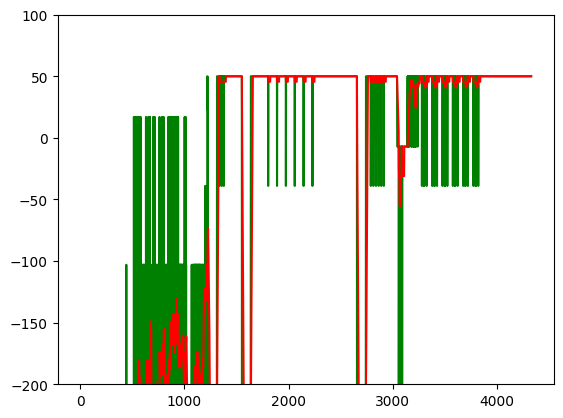

In [22]:
import matplotlib.pyplot as plt

# ---- Moving average ----
window_size = 20
moving_avg = []
for i in range(len(HUMAN_REWARD)):
    if i < window_size:
        moving_avg.append(np.mean(HUMAN_REWARD[:i+1]))
    else:
        moving_avg.append(np.mean(HUMAN_REWARD[i-window_size+1:i+1]))

plt.plot(HUMAN_REWARD, color="green")
plt.plot(moving_avg, color="red")
plt.ylim(-200, 100)
plt.show()

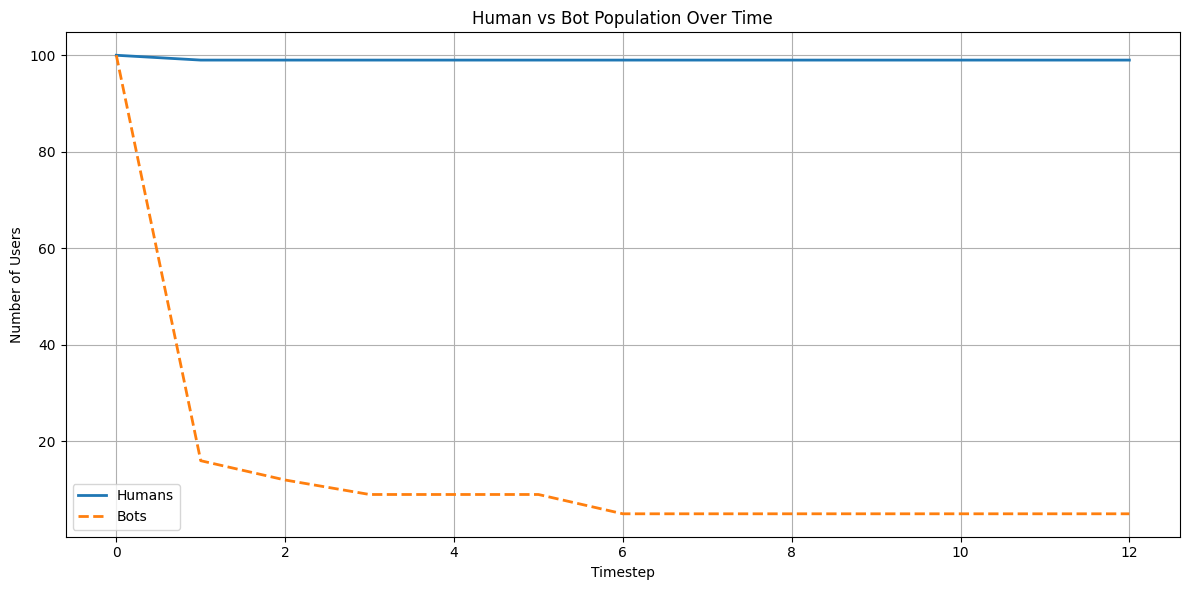

In [23]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))

plt.plot(timestep_counts, human_counts,
         label="Humans",
         linestyle="-",
         linewidth=2)

plt.plot(timestep_counts, bot_counts,
         label="Bots",
         linestyle="--",
         linewidth=2)

plt.xlabel("Timestep")
plt.ylabel("Number of Users")
plt.title("Human vs Bot Population Over Time")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()